Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...
Procesando mensajes VIBE...
Campos encontrados en VIBE: dict_keys(['mavpackettype', 'TimeUS', 'IMU', 'VibeX', 'VibeY', 'VibeZ', 'Clip'])


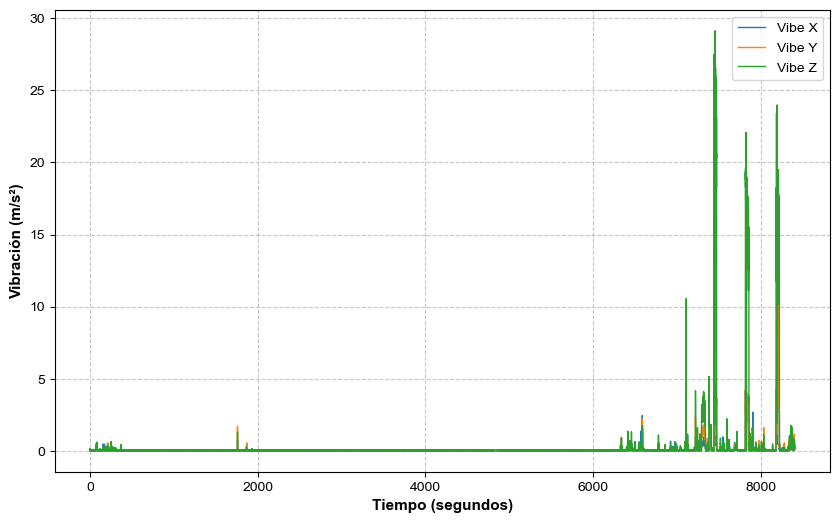

Gráfica generada exitosamente como: grafica_vibraciones_apa.png


In [4]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN ---
# Usa r'' para evitar problemas con rutas en Windows
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

# Verificación de seguridad de ruta
if not os.path.exists(log_file):
    # Intento de ruta absoluta alternativa (ajusta tu usuario si es necesario)
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

# Listas para almacenar datos (Quitamos Clip0 para evitar el error)
data = {'TimeUS': [], 'VibeX': [], 'VibeY': [], 'VibeZ': []}

# --- EXTRACCIÓN DE DATOS ---
print("Procesando mensajes VIBE...")
first_msg = True

while True:
    msg = mlog.recv_match(type='VIBE', blocking=False)
    if not msg:
        break
    
    # --- DEPURACIÓN: Ver qué campos existen realmente ---
    if first_msg:
        print(f"Campos encontrados en VIBE: {msg.to_dict().keys()}")
        first_msg = False
    
    # Extraer datos (Usamos getattr para evitar errores si falta algún campo)
    data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
    data['VibeX'].append(getattr(msg, 'VibeX', 0))
    data['VibeY'].append(getattr(msg, 'VibeY', 0))
    data['VibeZ'].append(getattr(msg, 'VibeZ', 0))
    # data['Clip0'] eliminada para que no falle el script

# Crear DataFrame
df = pd.DataFrame(data)

if df.empty:
    print("Error: No se encontraron datos de vibración (VIBE) en el log.")
else:
    # Convertir tiempo a segundos
    df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

    # --- GRAFICACIÓN ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']

    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar Vibraciones
    ax.plot(df['TimeSec'], df['VibeX'], label='Vibe X', linewidth=1)
    ax.plot(df['TimeSec'], df['VibeY'], label='Vibe Y', linewidth=1)
    ax.plot(df['TimeSec'], df['VibeZ'], label='Vibe Z', linewidth=1)

    # Etiquetas y Estilo APA
    ax.set_xlabel('Tiempo (segundos)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Vibración (m/s²)', fontsize=11, fontweight='bold')
    
    # Título comentado para la tesis (se pone en el caption de Word/LaTeX)
    # ax.set_title('Análisis de Vibraciones', fontsize=12, style='italic') 
    
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # Guardar
    output_img = 'grafica_vibraciones_apa.png'
    plt.savefig(output_img, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Gráfica generada exitosamente como: {output_img}")

Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...
Procesando mensajes VIBE...


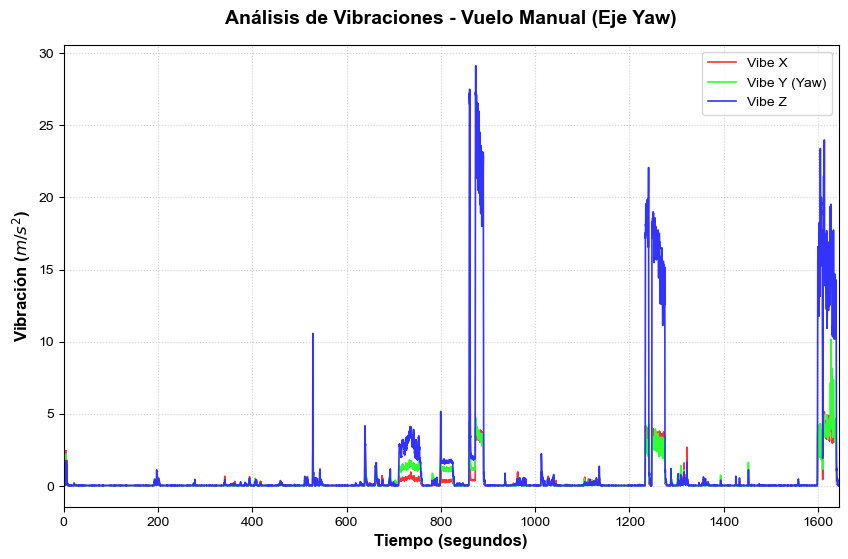

✅ ¡Listo! Imagen guardada como: grafica_vibraciones_yaw_manual.png
Duración del intervalo graficado: 1643.76 segundos


In [5]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DEL ARCHIVO ---
# Usa r'' para evitar problemas con las barras en Windows
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

# Verificación de que el archivo existe
if not os.path.exists(log_file):
    # Ruta alternativa (ajusta tu usuario si es necesario)
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

# --- 2. EXTRACCIÓN DE DATOS ---
# Eliminamos 'Clip0' para evitar el error anterior
data = {'TimeUS': [], 'VibeX': [], 'VibeY': [], 'VibeZ': []}

print("Procesando mensajes VIBE...")
while True:
    msg = mlog.recv_match(type='VIBE', blocking=False)
    if not msg:
        break
    
    data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
    data['VibeX'].append(getattr(msg, 'VibeX', 0))
    data['VibeY'].append(getattr(msg, 'VibeY', 0))
    data['VibeZ'].append(getattr(msg, 'VibeZ', 0))

df = pd.DataFrame(data)

if df.empty:
    print("Error: No hay datos VIBE.")
else:
    # Convertir tiempo a segundos (iniciando en 0)
    df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

    # ---------------------------------------------------------
    # --- 3. SECCIÓN DE RECORTE (ZOOM) ---
    # ---------------------------------------------------------
    # Ajusta estos valores mirando tu gráfica completa si es necesario.
    # La maniobra dura aprox 45 segundos (de 02:16:26 a 02:17:11).
    # Aquí buscamos automáticamente donde empieza la vibración fuerte
    # para intentar coincidir con tu imagen automáticamente.
    
    # OPCIÓN AUTOMÁTICA (Intenta detectar el movimiento):
    # Filtramos donde la vibración Y sea mayor a 2 m/s² para encontrar la maniobra
    actividad = df[df['VibeY'] > 2] 
    
    if not actividad.empty:
        # Damos un margen de 5 segundos antes y después
        inicio_segundos = actividad['TimeSec'].min() - 5
        fin_segundos = actividad['TimeSec'].max() + 5
    else:
        # Si no detecta auto, usa todo el vuelo (tú puedes cambiar estos números manualmente)
        inicio_segundos = df['TimeSec'].min()
        fin_segundos = df['TimeSec'].max()

    # Aplicar el filtro de tiempo
    df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]
    
    # Recalcular el tiempo para que empiece en 0 en la gráfica (más limpio para la tesis)
    # Opcional: si prefieres mantener el tiempo absoluto del vuelo, comenta la siguiente línea
    df_zoom = df_zoom.copy() # Evitar warning de pandas
    df_zoom['TimeRelativo'] = df_zoom['TimeSec'] - df_zoom['TimeSec'].iloc[0]

    # ---------------------------------------------------------
    # --- 4. GRAFICACIÓN (ESTILO ACADÉMICO / APA) ---
    # ---------------------------------------------------------
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial'] # Arial es estándar APA

    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar datos recortados
    # Eje X: Usamos TimeRelativo (0 a 45s aprox) o TimeSec (segundo real del vuelo)
    eje_x = df_zoom['TimeRelativo'] 
    
    ax.plot(eje_x, df_zoom['VibeX'], label='Vibe X', color='#FF3333', linewidth=1.2) # Rojo
    ax.plot(eje_x, df_zoom['VibeY'], label='Vibe Y (Yaw)', color='#33FF33', linewidth=1.2) # Verde
    ax.plot(eje_x, df_zoom['VibeZ'], label='Vibe Z', color='#3333FF', linewidth=1.2) # Azul

    # Títulos y Etiquetas (En Español y Negrita)
    ax.set_title('Análisis de Vibraciones - Vuelo Manual (Eje Yaw)', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo (segundos)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Vibración ($m/s^2$)', fontsize=12, fontweight='bold')
    
    # Leyenda y Grid
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Límites (Opcional, para asegurar que se vea ajustado)
    ax.set_xlim(left=0, right=eje_x.max())

    # --- 5. GUARDAR PARA OVERLEAF ---
    nombre_archivo = 'grafica_vibraciones_yaw_manual.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ ¡Listo! Imagen guardada como: {nombre_archivo}")
    print(f"Duración del intervalo graficado: {fin_segundos - inicio_segundos:.2f} segundos")

Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...
Procesando mensajes VIBE...
Filtrando datos entre 8170 y 8225 segundos...


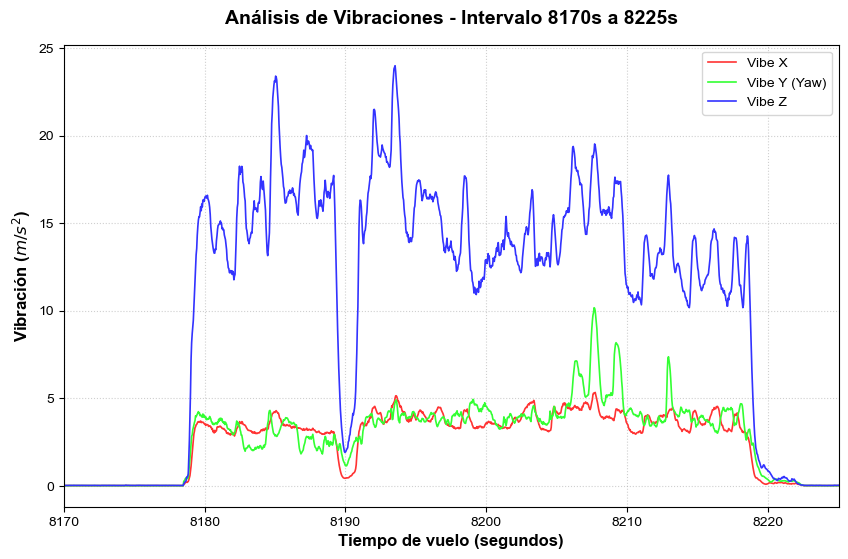

✅ ¡Listo! Imagen guardada como: grafica_vibraciones_yaw_manual.png


In [11]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DEL ARCHIVO ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

# --- 2. EXTRACCIÓN DE DATOS ---
data = {'TimeUS': [], 'VibeX': [], 'VibeY': [], 'VibeZ': []}

print("Procesando mensajes VIBE...")
while True:
    msg = mlog.recv_match(type='VIBE', blocking=False)
    if not msg:
        break
    
    data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
    data['VibeX'].append(getattr(msg, 'VibeX', 0))
    data['VibeY'].append(getattr(msg, 'VibeY', 0))
    data['VibeZ'].append(getattr(msg, 'VibeZ', 0))

df = pd.DataFrame(data)

if df.empty:
    print("Error: No hay datos VIBE.")
else:
    # Convertir tiempo a segundos (iniciando en 0)
    df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

    # ---------------------------------------------------------
    # --- 3. SECCIÓN DE RECORTE (MANUAL 8000-9000) ---
    # ---------------------------------------------------------
    # Rango manual solicitado
    inicio_segundos = 8170
    fin_segundos = 8225

    print(f"Filtrando datos entre {inicio_segundos} y {fin_segundos} segundos...")

    # Aplicar el filtro de tiempo
    df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]
    
    if df_zoom.empty:
        print("ADVERTENCIA: No hay datos en ese rango de tiempo (8170-8225s). Verifica la duración del log.")
    else:
        # Recalcular el tiempo para que empiece en 0 en la gráfica (tiempo relativo al recorte)
        # Si prefieres ver "8000" en el eje X, comenta las dos líneas siguientes:
        df_zoom = df_zoom.copy() 
        df_zoom['TimeRelativo'] = df_zoom['TimeSec'] - df_zoom['TimeSec'].iloc[0]

        # ---------------------------------------------------------
        # --- 4. GRAFICACIÓN (ESTILO ACADÉMICO / APA) ---
        # ---------------------------------------------------------
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = ['Arial']

        fig, ax = plt.subplots(figsize=(10, 6))

        # Eje X: TimeRelativo (0 a 1000s aprox) 
        # Si quieres ver el tiempo real del vuelo usa df_zoom['TimeSec']
        eje_x = df_zoom['TimeSec'] 
        
        ax.plot(eje_x, df_zoom['VibeX'], label='Vibe X', color='#FF3333', linewidth=1.2)
        ax.plot(eje_x, df_zoom['VibeY'], label='Vibe Y (Yaw)', color='#33FF33', linewidth=1.2)
        ax.plot(eje_x, df_zoom['VibeZ'], label='Vibe Z', color='#3333FF', linewidth=1.2)

        # Títulos y Etiquetas
        ax.set_title('Análisis de Vibraciones - Intervalo 8170s a 8225s', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Vibración ($m/s^2$)', fontsize=12, fontweight='bold')
        
        ax.legend(loc='upper right', frameon=True, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        # Ajustar límites del eje X
        ax.set_xlim(left=inicio_segundos, right=fin_segundos)

        # --- 5. GUARDAR PARA OVERLEAF ---
        nombre_archivo = 'grafica_vibraciones_yaw_manual.png'
        plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ ¡Listo! Imagen guardada como: {nombre_archivo}")

Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...
Procesando mensajes ATT (Actitud)...
Filtrando datos de Yaw entre 8170 y 8225 segundos...


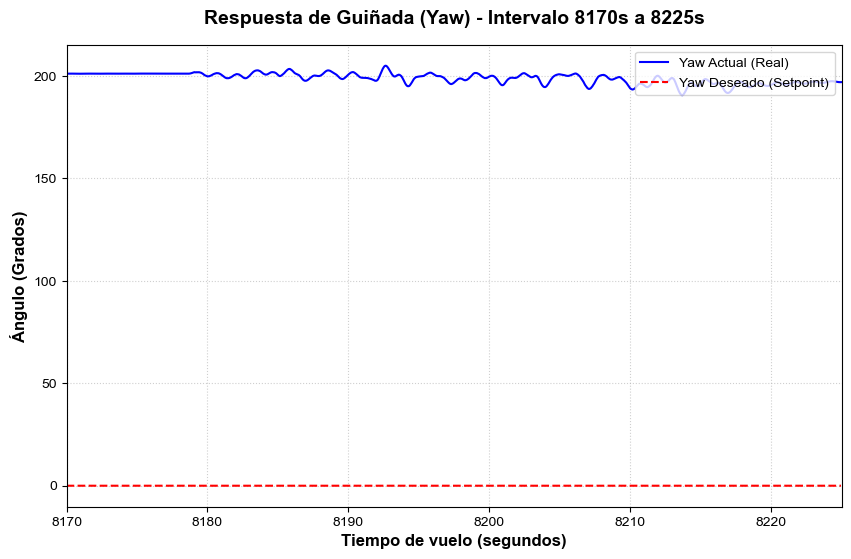

✅ ¡Listo! Imagen guardada como: grafica_att_yaw_manual.png


In [12]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DEL ARCHIVO ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

# --- 2. EXTRACCIÓN DE DATOS (CAMBIO A MENSAJE 'ATT') ---
# ATT contiene los datos de actitud (Roll, Pitch, Yaw)
data = {'TimeUS': [], 'Yaw': [], 'DesYaw': []}

print("Procesando mensajes ATT (Actitud)...")
while True:
    # Cambiamos 'VIBE' por 'ATT'
    msg = mlog.recv_match(type='ATT', blocking=False)
    if not msg:
        break
    
    data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
    data['Yaw'].append(getattr(msg, 'Yaw', 0))
    data['DesYaw'].append(getattr(msg, 'DesYaw', 0))

df = pd.DataFrame(data)

if df.empty:
    print("Error: No hay datos ATT.")
else:
    # Convertir tiempo a segundos
    df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

    # ---------------------------------------------------------
    # --- 3. SECCIÓN DE RECORTE (MANUAL 8170-8225) ---
    # ---------------------------------------------------------
    inicio_segundos = 8170
    fin_segundos = 8225

    print(f"Filtrando datos de Yaw entre {inicio_segundos} y {fin_segundos} segundos...")

    # Aplicar el filtro
    df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]
    
    if df_zoom.empty:
        print("ADVERTENCIA: No hay datos en ese rango de tiempo.")
    else:
        # ---------------------------------------------------------
        # --- 4. GRAFICACIÓN (ESTILO ACADÉMICO / APA) ---
        # ---------------------------------------------------------
        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = ['Arial']

        fig, ax = plt.subplots(figsize=(10, 6))

        eje_x = df_zoom['TimeSec'] 
        
        # Graficar Yaw Real y Deseado
        # Nota: Si el avión cruza el Norte (0 grados), la gráfica puede saltar de 360 a 0.
        ax.plot(eje_x, df_zoom['Yaw'], label='Yaw Actual (Real)', color='blue', linewidth=1.5)
        
        # El DesYaw a veces es 0 en modo totalmente Manual, pero en Stabilize/FBWA muestra la intención
        ax.plot(eje_x, df_zoom['DesYaw'], label='Yaw Deseado (Setpoint)', color='red', linestyle='--', linewidth=1.5)

        # Títulos y Etiquetas
        ax.set_title('Respuesta de Guiñada (Yaw) - Intervalo 8170s a 8225s', fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Ángulo (Grados)', fontsize=12, fontweight='bold')
        
        ax.legend(loc='upper right', frameon=True, fontsize=10)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        ax.set_xlim(left=inicio_segundos, right=fin_segundos)

        # --- 5. GUARDAR ---
        nombre_archivo = 'grafica_att_yaw_manual.png'
        plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ ¡Listo! Imagen guardada como: {nombre_archivo}")

Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...
Procesando mensajes RCIN y RCOU...
Filtrando intervalo 8170-8225s...


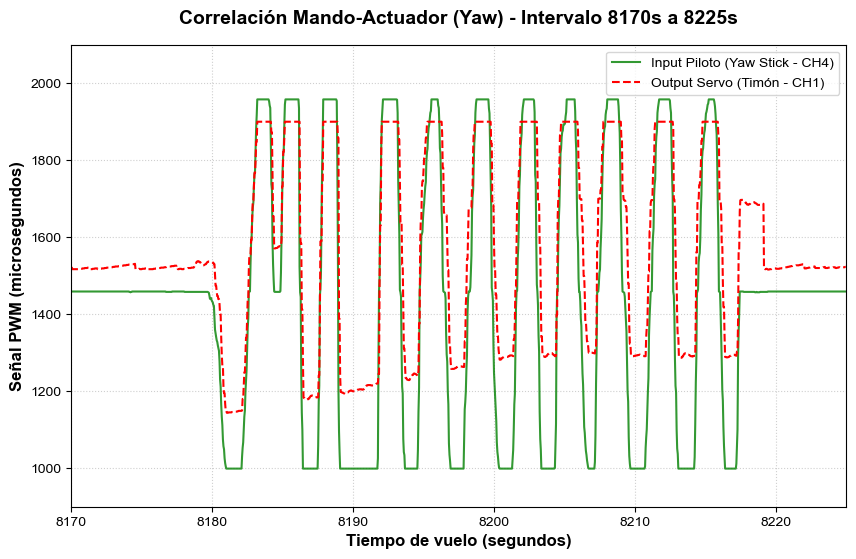

✅ Imagen guardada como: grafica_rcin_rcou_yaw.png


In [13]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

# --- 2. EXTRACCIÓN DE DATOS ---
# Necesitamos dos estructuras separadas porque RCIN y RCOU no siempre se graban al mismo tiempo exacto
rc_data = {'TimeUS': [], 'C4': []}    # Input del Piloto (Yaw Stick)
servo_data = {'TimeUS': [], 'C1': []} # Output al Servo (Rudder)

print("Procesando mensajes RCIN y RCOU...")
while True:
    # Pedimos ambos tipos de mensaje
    msg = mlog.recv_match(type=['RCIN', 'RCOU'], blocking=False)
    if not msg:
        break
    
    msg_type = msg.get_type()
    
    if msg_type == 'RCIN':
        rc_data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        rc_data['C4'].append(getattr(msg, 'C4', 0)) # Canal 4: Yaw Stick
        
    elif msg_type == 'RCOU':
        servo_data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        servo_data['C1'].append(getattr(msg, 'C1', 0)) # Canal 1: Rudder Servo (Según tu imagen)

# Crear DataFrames
df_rc = pd.DataFrame(rc_data)
df_servo = pd.DataFrame(servo_data)

if df_rc.empty or df_servo.empty:
    print("Error: Faltan datos de RCIN o RCOU.")
else:
    # Convertir tiempo a segundos y ajustar el cero
    start_time = min(df_rc['TimeUS'].iloc[0], df_servo['TimeUS'].iloc[0])
    
    df_rc['TimeSec'] = (df_rc['TimeUS'] - start_time) / 1e6
    df_servo['TimeSec'] = (df_servo['TimeUS'] - start_time) / 1e6

    # ---------------------------------------------------------
    # --- 3. SECCIÓN DE RECORTE (8170 - 8225s) ---
    # ---------------------------------------------------------
    inicio_segundos = 8170
    fin_segundos = 8225

    print(f"Filtrando intervalo {inicio_segundos}-{fin_segundos}s...")

    # Recortamos ambos dataframes independientemente
    rc_zoom = df_rc[(df_rc['TimeSec'] >= inicio_segundos) & (df_rc['TimeSec'] <= fin_segundos)]
    servo_zoom = df_servo[(df_servo['TimeSec'] >= inicio_segundos) & (df_servo['TimeSec'] <= fin_segundos)]

    # ---------------------------------------------------------
    # --- 4. GRAFICACIÓN ---
    # ---------------------------------------------------------
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']

    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar Input del Piloto (RCIN C4)
    # Usamos un color verde para el input (mando)
    ax.plot(rc_zoom['TimeSec'], rc_zoom['C4'], label='Input Piloto (Yaw Stick - CH4)', 
            color='green', linewidth=1.5, alpha=0.8)
    
    # Graficar Output del Servo (RCOU C1)
    # Usamos rojo para la respuesta del servo, igual que en tu imagen de referencia
    ax.plot(servo_zoom['TimeSec'], servo_zoom['C1'], label='Output Servo (Timón - CH1)', 
            color='red', linewidth=1.5, linestyle='--')

    # Configuración
    ax.set_title('Correlación Mando-Actuador (Yaw) - Intervalo 8170s a 8225s', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Señal PWM (microsegundos)', fontsize=12, fontweight='bold')
    
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Límites
    ax.set_xlim(left=inicio_segundos, right=fin_segundos)
    
    # Ajuste del eje Y para ver mejor los PWM (1000 a 2000 es el rango estándar)
    ax.set_ylim(900, 2100) 

    # --- 5. GUARDAR ---
    nombre_archivo = 'grafica_rcin_rcou_yaw.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Imagen guardada como: {nombre_archivo}")

Generando gráfica para intervalo: 02:10:20.000 a 02:11:10.000
(7820.0s - 7870.0s)
Leyendo log: C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN...


C:\Users\stemjara\AppData\Local\Temp\ipykernel_31404\2199870117.py:61: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('TimeUS').fillna(method='ffill').dropna()


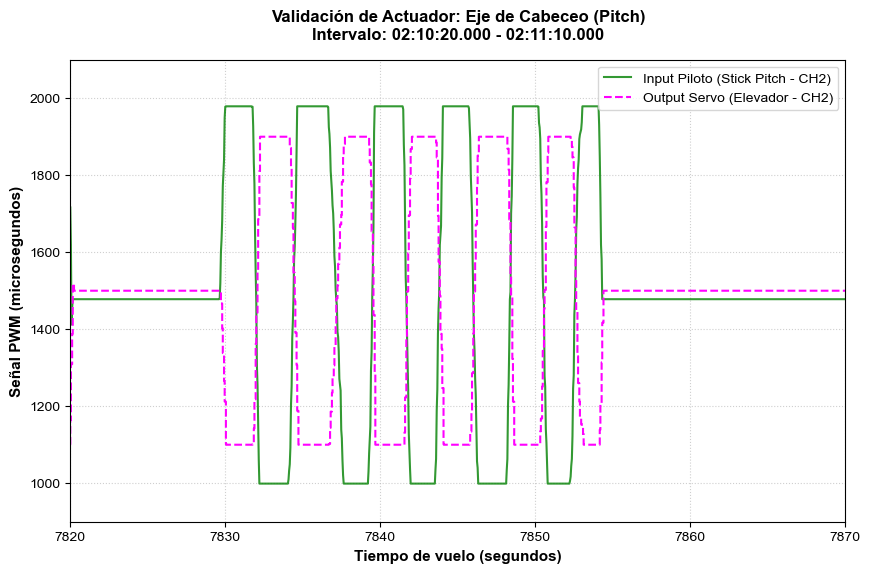

✅ Gráfica guardada como: grafica_validacion_pitch.png


In [20]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

# Rutina de seguridad para encontrar el archivo
if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

# --- FUNCIÓN AUXILIAR PARA TIEMPO ---
def timestamp_to_seconds(time_str):
    """Convierte formato HH:MM:SS o HH:MM:SS.mmm a segundos totales"""
    parts = time_str.split(':')
    h = float(parts[0])
    m = float(parts[1])
    s = float(parts[2])
    return (h * 3600) + (m * 60) + s

# --- 2. DEFINICIÓN DEL INTERVALO (LO QUE VES EN MISSION PLANNER) ---
t_inicio_str = "02:10:20.000"
t_fin_str    = "02:11:10.000"

# Convertimos automáticamente a segundos
inicio_segundos = timestamp_to_seconds(t_inicio_str)
fin_segundos = timestamp_to_seconds(t_fin_str)

print(f"Generando gráfica para intervalo: {t_inicio_str} a {t_fin_str}")
print(f"({inicio_segundos}s - {fin_segundos}s)")

# --- 3. EXTRACCIÓN DE DATOS ---
print(f"Leyendo log: {log_file}...")
mlog = mavutil.mavlink_connection(log_file)

data = {'TimeUS': [], 'RC_Pitch': [], 'Servo_Elevator': []}

while True:
    # Filtramos solo canales 2 (Pitch/Elevator)
    msg = mlog.recv_match(type=['RCIN', 'RCOU'], blocking=False)
    if not msg:
        break
    
    msg_type = msg.get_type()
    
    if msg_type == 'RCIN':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Pitch'].append(getattr(msg, 'C2', None)) # Canal 2 Entrada
        data['Servo_Elevator'].append(None)
        
    elif msg_type == 'RCOU':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Pitch'].append(None)
        data['Servo_Elevator'].append(getattr(msg, 'C2', None)) # Canal 2 Salida

# Crear DataFrame
df = pd.DataFrame(data)
df = df.sort_values('TimeUS').fillna(method='ffill').dropna()

# Convertir TimeUS a Segundos
# NOTA: Asumimos que el tiempo 00:00:00 es el inicio del log.
df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

# --- 4. FILTRADO POR TIEMPO ---
df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]

if df_zoom.empty:
    print("ADVERTENCIA: No se encontraron datos en ese rango de tiempo.")
else:
    # --- 5. GRAFICACIÓN ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    eje_x = df_zoom['TimeSec']

    # Graficar Entrada (Mando Piloto) - Verde
    ax.plot(eje_x, df_zoom['RC_Pitch'], label='Input Piloto (Stick Pitch - CH2)', 
            color='green', linewidth=1.5, alpha=0.8)
    
    # Graficar Salida (Servo) - Magenta (para diferenciar del rojo del Yaw)
    ax.plot(eje_x, df_zoom['Servo_Elevator'], label='Output Servo (Elevador - CH2)', 
            color='magenta', linewidth=1.5, linestyle='--')

    # Configuración Estética
    ax.set_title(f'Validación de Actuador: Eje de Cabeceo (Pitch)\nIntervalo: {t_inicio_str} - {t_fin_str}', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Señal PWM (microsegundos)', fontsize=11, fontweight='bold')
    
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    # Límites
    ax.set_xlim(left=inicio_segundos, right=fin_segundos)
    ax.set_ylim(900, 2100) # Rango PWM estándar

    # Guardar
    nombre_archivo = 'grafica_validacion_pitch.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gráfica guardada como: {nombre_archivo}")

Generando gráfica de ROLL para: 02:03:39.000 - 02:06:09.000
Leyendo log...


C:\Users\stemjara\AppData\Local\Temp\ipykernel_31404\2386330480.py:54: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('TimeUS').fillna(method='ffill').dropna()


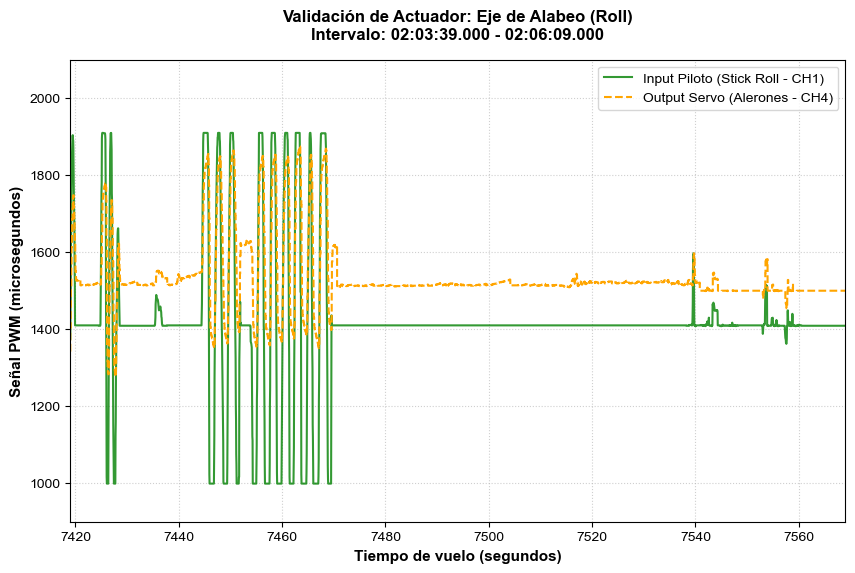

✅ Gráfica guardada como: grafica_validacion_roll.png


In [21]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

# Función para convertir HH:MM:SS a segundos
def timestamp_to_seconds(time_str):
    parts = time_str.split(':')
    return (float(parts[0]) * 3600) + (float(parts[1]) * 60) + float(parts[2])

# --- 2. DEFINICIÓN DEL INTERVALO (ROLL) ---
t_inicio_str = "02:03:39.000"
t_fin_str    = "02:06:09.000"

inicio_segundos = timestamp_to_seconds(t_inicio_str)
fin_segundos = timestamp_to_seconds(t_fin_str)

print(f"Generando gráfica de ROLL para: {t_inicio_str} - {t_fin_str}")

# --- 3. EXTRACCIÓN DE DATOS ---
print(f"Leyendo log...")
mlog = mavutil.mavlink_connection(log_file)

data = {'TimeUS': [], 'RC_Roll': [], 'Servo_Aileron': []}

while True:
    # Filtramos mensajes RCIN (Entrada) y RCOU (Salida)
    msg = mlog.recv_match(type=['RCIN', 'RCOU'], blocking=False)
    if not msg:
        break
    
    msg_type = msg.get_type()
    
    if msg_type == 'RCIN':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Roll'].append(getattr(msg, 'C1', None)) # Canal 1: Stick Roll
        data['Servo_Aileron'].append(None)
        
    elif msg_type == 'RCOU':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Roll'].append(None)
        data['Servo_Aileron'].append(getattr(msg, 'C4', None)) # Canal 4: Servo Alerones

# Crear DataFrame y rellenar huecos
df = pd.DataFrame(data)
df = df.sort_values('TimeUS').fillna(method='ffill').dropna()

# Convertir tiempo
df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

# --- 4. FILTRADO POR TIEMPO ---
df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]

if df_zoom.empty:
    print("ADVERTENCIA: No hay datos en ese rango.")
else:
    # --- 5. GRAFICACIÓN ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    eje_x = df_zoom['TimeSec']

    # Graficar Entrada (Verde para consistencia con los anteriores)
    ax.plot(eje_x, df_zoom['RC_Roll'], label='Input Piloto (Stick Roll - CH1)', 
            color='green', linewidth=1.5, alpha=0.8)
    
    # Graficar Salida (Naranja para diferenciar del rojo y magenta usados antes)
    ax.plot(eje_x, df_zoom['Servo_Aileron'], label='Output Servo (Alerones - CH4)', 
            color='orange', linewidth=1.5, linestyle='--')

    # Configuración
    ax.set_title(f'Validación de Actuador: Eje de Alabeo (Roll)\nIntervalo: {t_inicio_str} - {t_fin_str}', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Señal PWM (microsegundos)', fontsize=11, fontweight='bold')
    
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    ax.set_xlim(left=inicio_segundos, right=fin_segundos)
    ax.set_ylim(900, 2100)

    # Guardar
    nombre_archivo = 'grafica_validacion_roll.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gráfica guardada como: {nombre_archivo}")

Generando gráfica de THROTTLE para: 02:16:12.000 - 02:17:12.000
Leyendo log...


C:\Users\stemjara\AppData\Local\Temp\ipykernel_31404\3326189985.py:53: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('TimeUS').fillna(method='ffill').dropna()


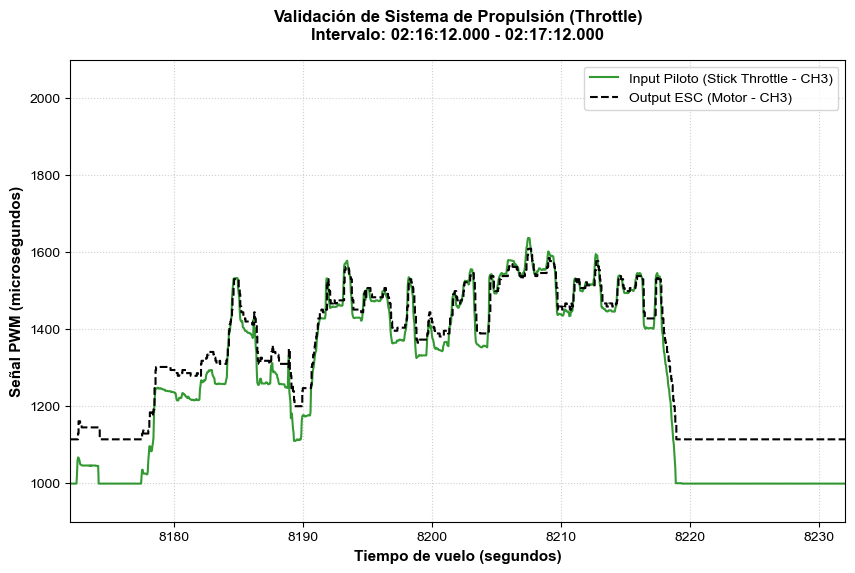

✅ Gráfica guardada como: grafica_validacion_throttle.png


In [23]:
from pymavlink import mavutil
import pandas as pd
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN ---
log_file = r'Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN' 

if not os.path.exists(log_file):
    log_file = r'C:/Users/stemjara/Documents/GitRepositories/MissionPlanerRenoL250/00000009.BIN'
    if not os.path.exists(log_file):
        raise FileNotFoundError(f"No se encuentra el archivo en: {log_file}")

def timestamp_to_seconds(time_str):
    parts = time_str.split(':')
    return (float(parts[0]) * 3600) + (float(parts[1]) * 60) + float(parts[2])

# --- 2. DEFINICIÓN DEL INTERVALO (THROTTLE) ---
# Intervalo solicitado: 02:16:12 a 02:18:00
t_inicio_str = "02:16:12.000"
t_fin_str    = "02:17:12.000"

inicio_segundos = timestamp_to_seconds(t_inicio_str)
fin_segundos = timestamp_to_seconds(t_fin_str)

print(f"Generando gráfica de THROTTLE para: {t_inicio_str} - {t_fin_str}")

# --- 3. EXTRACCIÓN DE DATOS ---
print(f"Leyendo log...")
mlog = mavutil.mavlink_connection(log_file)

data = {'TimeUS': [], 'RC_Thr': [], 'Servo_Thr': []}

while True:
    msg = mlog.recv_match(type=['RCIN', 'RCOU'], blocking=False)
    if not msg:
        break
    
    msg_type = msg.get_type()
    
    if msg_type == 'RCIN':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Thr'].append(getattr(msg, 'C3', None)) # Canal 3: Stick Acelerador
        data['Servo_Thr'].append(None)
        
    elif msg_type == 'RCOU':
        data['TimeUS'].append(getattr(msg, 'TimeUS', 0))
        data['RC_Thr'].append(None)
        data['Servo_Thr'].append(getattr(msg, 'C3', None)) # Canal 3: Salida a ESC

# Crear DataFrame
df = pd.DataFrame(data)
df = df.sort_values('TimeUS').fillna(method='ffill').dropna()

# Convertir tiempo
df['TimeSec'] = (df['TimeUS'] - df['TimeUS'].iloc[0]) / 1e6

# --- 4. FILTRADO POR TIEMPO ---
df_zoom = df[(df['TimeSec'] >= inicio_segundos) & (df['TimeSec'] <= fin_segundos)]

if df_zoom.empty:
    print("ADVERTENCIA: No hay datos en ese rango.")
else:
    # --- 5. GRAFICACIÓN ---
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = ['Arial']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    eje_x = df_zoom['TimeSec']

    # Graficar Entrada (Verde)
    ax.plot(eje_x, df_zoom['RC_Thr'], label='Input Piloto (Stick Throttle - CH3)', 
            color='green', linewidth=1.5, alpha=0.8)
    
    # Graficar Salida (Rojo/Negro)
    ax.plot(eje_x, df_zoom['Servo_Thr'], label='Output ESC (Motor - CH3)', 
            color='black', linewidth=1.5, linestyle='--')

    # Configuración
    ax.set_title(f'Validación de Sistema de Propulsión (Throttle)\nIntervalo: {t_inicio_str} - {t_fin_str}', 
                 fontsize=12, fontweight='bold', pad=15)
    ax.set_xlabel('Tiempo de vuelo (segundos)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Señal PWM (microsegundos)', fontsize=11, fontweight='bold')
    
    ax.legend(loc='upper right', frameon=True, fontsize=10)
    ax.grid(True, linestyle=':', alpha=0.6)
    
    ax.set_xlim(left=inicio_segundos, right=fin_segundos)
    # Ajustamos eje Y para ver bien el PWM (normalmente 1000 a 2000)
    ax.set_ylim(900, 2100)

    # Guardar
    nombre_archivo = 'grafica_validacion_throttle.png'
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Gráfica guardada como: {nombre_archivo}")